Processing: ../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_10.dm3


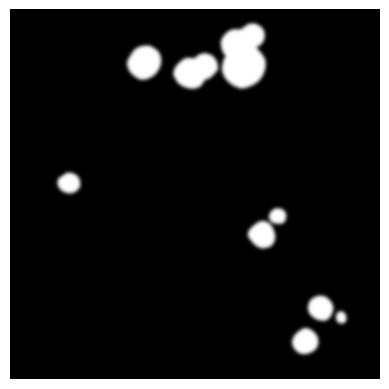

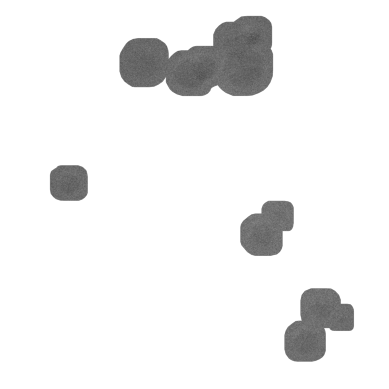

Processing: ../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_12.dm3


KeyboardInterrupt: 

In [10]:
import os
import glob
from ncempy.io import dm
from pathlib import Path
import matplotlib.image as mpimg
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

for dm3_file in glob.glob(os.path.join("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/", "*.dm3")):
    truth_image = dm3_file.replace("/2022_02_02 5nm Ag nanoparticles on UTC/", "/2022_02_02 5nm Ag nanoparticles on UTC/Labels/").replace(".dm3", "_label.png")
    truth_image = mpimg.imread(truth_image)

    print("Processing:", dm3_file)

    data_dict = dm.dmReader(str(Path(dm3_file).resolve()))
    image = data_dict['data']
    blurred = gaussian_filter(truth_image, sigma=20)
    mask = blurred > 0
    plt.imshow(blurred, cmap="gray")
    plt.axis("off")
    plt.show()
    masked_image = np.where(mask, image, np.nan)

    plt.imshow(masked_image, cmap="gray")
    plt.axis("off")
    plt.show()




In [11]:
import pandas as pd

df = pd.read_parquet("masked_images.parquet")

print(df.head())
print(df.shape)

                                               image  \
0  /data/test_images/2022_02_02 5nm Ag nanopartic...   
1  /data/test_images/2022_02_02 5nm Ag nanopartic...   
2  /data/test_images/2022_02_02 5nm Ag nanopartic...   
3  /data/test_images/2022_02_02 5nm Ag nanopartic...   
4  /data/test_images/2022_02_02 5nm Ag nanopartic...   

                                           clustered  \
0  [2, 0, 0, 1, 3, 2, 3, 2, 2, 0, 3, 3, 2, 2, 2, ...   
1  [2, 0, 2, 3, 1, 3, 3, 0, 2, 1, 0, 3, 3, 2, 2, ...   
2  [1, 0, 0, 1, 1, 0, 1, 1, 2, 1, 2, 0, 1, 0, 0, ...   
3  [3, 1, 3, 2, 3, 3, 3, 3, 1, 2, 1, 2, 3, 1, 1, ...   
4  [3, 0, 0, 1, 0, 1, 1, 3, 1, 3, 3, 1, 3, 1, 0, ...   

                                           positions  
0  [[0, 0], [0, 8], [0, 16], [0, 24], [0, 32], [0...  
1  [[0, 0], [0, 8], [0, 16], [0, 24], [0, 32], [0...  
2  [[0, 0], [0, 8], [0, 16], [0, 24], [0, 32], [0...  
3  [[0, 0], [0, 8], [0, 16], [0, 24], [0, 32], [0...  
4  [[0, 0], [0, 8], [0, 16], [0, 24], [0, 32], [0..

In [1]:
import glob
import os
from ncempy.io import dm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.preprocessing import StandardScaler
import umap
from sklearn.cluster import KMeans
from skimage.util import view_as_windows
import numpy as np
from persim import PersistenceImager
from ripser import lower_star_img
import pandas as pd
from itertools import islice

def label_to_image(original_image, labels, positions, patch_size=16):
    H, W = original_image.shape[:2]

    label_img = np.zeros((H, W), dtype=np.uint8)
    vote_img  = np.zeros((H, W), dtype=np.uint8)

    for (r, c), lab in zip(positions, labels):
        r_end = min(r + patch_size, H)
        c_end = min(c + patch_size, W)

        region = (slice(r, r_end), slice(c, c_end))

        votes = vote_img[region] + 1

        mask = votes >= vote_img[region]

        label_patch = label_img[region]
        label_patch[mask] = lab

        vote_img[region][mask] = votes[mask]

    return label_img

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
import numpy as np
from skimage.morphology import remove_small_objects
from scipy.ndimage import binary_fill_holes
from skimage.morphology import binary_closing, disk
from pathlib import Path

image_dir = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/")
labels_dir = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/Labels")

output = Path("./cluster_results")


for id, row in df.iterrows():

    image_name = Path(row["image"]).stem
    out_dir = output / image_name
    out_dir.mkdir(parents=True, exist_ok=True)  

    matches = list(image_dir.glob(f"{image_name}.dm3"))
    truths = list(labels_dir.glob(f"{image_name}_label.png"))

    if not matches:
        continue

    image_path = matches[0]
    truth_path = truths[0]
    data_dict = dm.dmReader(str(Path(image_path).resolve()))
    original_image = data_dict['data']
    truth_img = mpimg.imread(truth_path).astype(np.uint8)

    labels = row["clustered"]
    label_img = label_to_image(original_image, row["clustered"], row["positions"])
    output_path = out_dir / "labelimg.png"

    plt.imsave(output_path, label_img, cmap="tab20")

    clusters = [0,1,2,3,4,5,6,7]

    for i in clusters:

        pred_mask  = (label_img == i)        
        truth_mask = (truth_img > 0)  

        clean_mask = remove_small_objects(pred_mask, max_size=100)
        clean_mask = binary_fill_holes(clean_mask)
        clean_mask = binary_closing(clean_mask, footprint=disk(2))
        clean_mask = remove_small_objects(clean_mask, max_size=1600)

        intersection = (clean_mask & truth_mask).sum()
        union        = (clean_mask | truth_mask).sum()

        iou  = intersection / union                              

        print(f"Image {str(image_name)} Cluster {i} — IoU: {iou:.3f} ")

        plt.imsave(out_dir / f"cluster_{i}.png", pred_mask, cmap="tab20")

/tmp/ipykernel_10231/158711915.py:46: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


Image 20220202_Ag_UTC_330kx_2650e_0p1596s_08 Cluster 0 — IoU: 0.708 


/tmp/ipykernel_10231/158711915.py:46: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


Image 20220202_Ag_UTC_330kx_2650e_0p1596s_08 Cluster 1 — IoU: 0.000 


/tmp/ipykernel_10231/158711915.py:46: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


...

Image 20220202_Ag_UTC_330kx_2650e_0p1596s_11 Cluster 5 — IoU: 0.000 


/tmp/ipykernel_10231/158711915.py:46: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


Image 20220202_Ag_UTC_330kx_2650e_0p1596s_11 Cluster 6 — IoU: 0.000 


/tmp/ipykernel_10231/158711915.py:46: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


Image 20220202_Ag_UTC_330kx_2650e_0p1596s_11 Cluster 7 — IoU: 0.000 


In [2]:
import pandas as pd

df = pd.read_parquet("masked_images_64.parquet")

print(df.head())
print(df.shape)

                                               image  \
0  /data/test_images/2022_02_02 5nm Ag nanopartic...   
1  /data/test_images/2022_02_02 5nm Ag nanopartic...   
2  /data/test_images/2022_02_02 5nm Ag nanopartic...   
3  /data/test_images/2022_02_02 5nm Ag nanopartic...   
4  /data/test_images/2022_02_02 5nm Ag nanopartic...   

                                           clustered  \
0  [2, 1, 3, 3, 0, 1, 2, 3, 3, 0, 3, 2, 1, 2, 0, ...   
1  [3, 3, 0, 1, 1, 1, 1, 3, 3, 2, 2, 2, 2, 2, 2, ...   
2  [1, 2, 1, 2, 2, 2, 1, 3, 2, 2, 1, 2, 2, 1, 2, ...   
3  [2, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 2, 0, 2, 1, 0, 2, 1, 2, 2, 0, 1, 0, 1, 1, ...   

                                           positions  
0  [[0, 0], [0, 16], [0, 32], [0, 48], [0, 64], [...  
1  [[0, 0], [0, 16], [0, 32], [0, 48], [0, 64], [...  
2  [[0, 0], [0, 16], [0, 32], [0, 48], [0, 64], [...  
3  [[0, 0], [0, 16], [0, 32], [0, 48], [0, 64], [...  
4  [[0, 0], [0, 16], [0, 32], [0, 48], [0, 64], [..

In [3]:
import numpy as np
from skimage.morphology import remove_small_objects
from scipy.ndimage import binary_fill_holes
from skimage.morphology import binary_closing, disk
from pathlib import Path

image_dir = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/")
labels_dir = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/Labels")

output = Path("./cluster_results_64")


for id, row in df.iterrows():

    image_name = Path(row["image"]).stem
    out_dir = output / image_name
    out_dir.mkdir(parents=True, exist_ok=True)  

    matches = list(image_dir.glob(f"{image_name}.dm3"))
    truths = list(labels_dir.glob(f"{image_name}_label.png"))

    if not matches:
        continue

    image_path = matches[0]
    truth_path = truths[0]
    data_dict = dm.dmReader(str(Path(image_path).resolve()))
    original_image = data_dict['data']
    truth_img = mpimg.imread(truth_path).astype(np.uint8)

    labels = row["clustered"]
    label_img = label_to_image(original_image, row["clustered"], row["positions"])
    output_path = out_dir / "labelimg.png"

    plt.imsave(output_path, label_img, cmap="tab20")

    clusters = [0,1,2,3,4,5,6,7]

    for i in clusters:

        pred_mask  = (label_img == i)        
        truth_mask = (truth_img > 0)  

        clean_mask = remove_small_objects(pred_mask, max_size=100)
        clean_mask = binary_fill_holes(clean_mask)
        clean_mask = binary_closing(clean_mask, footprint=disk(2))
        clean_mask = remove_small_objects(clean_mask, max_size=1600)

        intersection = (clean_mask & truth_mask).sum()
        union        = (clean_mask | truth_mask).sum()

        iou  = intersection / union                              

        print(f"Image {str(image_name)} Cluster {i} — IoU: {iou:.3f} ")

        plt.imsave(out_dir / f"cluster_{i}.png", pred_mask, cmap="tab20")

/tmp/ipykernel_400938/3643016386.py:46: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


Image 20220202_Ag_UTC_330kx_2650e_0p1596s_08 Cluster 0 — IoU: 0.000 


/tmp/ipykernel_400938/3643016386.py:46: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


Image 20220202_Ag_UTC_330kx_2650e_0p1596s_08 Cluster 1 — IoU: 0.000 


/tmp/ipykernel_400938/3643016386.py:46: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


...

Image 20220202_Ag_UTC_330kx_2650e_0p1596s_11 Cluster 5 — IoU: 0.000 


/tmp/ipykernel_400938/3643016386.py:46: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


Image 20220202_Ag_UTC_330kx_2650e_0p1596s_11 Cluster 6 — IoU: 0.000 


/tmp/ipykernel_400938/3643016386.py:46: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


Image 20220202_Ag_UTC_330kx_2650e_0p1596s_11 Cluster 7 — IoU: 0.000 


In [15]:
import pandas as pd

df = pd.read_parquet("./output/masked_images_densities.parquet")

print(df.head())
print(df.shape)

                                               image  \
0  ../hrtem_files/2022_02_02 5nm Ag nanoparticles...   

                                    clustered_labels  \
0  [2, 0, 2, 2, 2, 3, 3, 3, 1, 2, 3, 3, 3, 1, 0, ...   

                                           positions  \
0  [[0, 0], [0, 16], [0, 32], [0, 48], [0, 64], [...   

                                           densities  
0  {"0": {"density_grid": [[1.3788671785763297e-0...  
(1, 4)


In [16]:
import numpy as np
from ncempy.io import dm
from pathlib import Path
row = df.iloc[0] 
image_path = row["image"]

data_dict = dm.dmReader(str(Path(image_path).resolve()))

image_data = data_dict['data']

labels = row["clustered_labels"]
positions =  row["positions"]


def label_to_image(original_image, labels, positions):

    H, W = original_image.shape[:2]
    label_img = np.zeros((H, W), dtype=int)

    for (r, c), lab in zip(positions, labels):
        label_img[r:r+16, c:c+16] = lab

    return label_img

label_img = label_to_image(image_data, labels, positions)

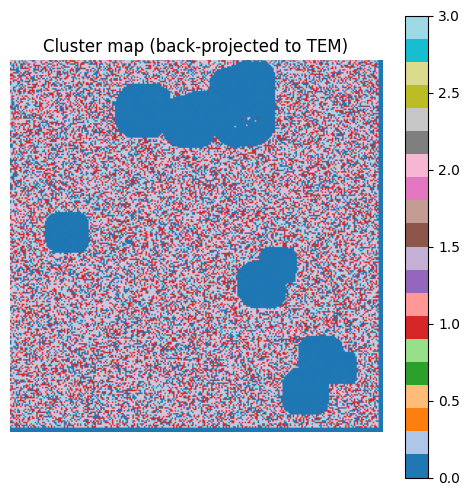

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(label_img, cmap="tab20")
plt.title("Cluster map (back-projected to TEM)")
plt.colorbar()
plt.axis("off")
plt.show()

In [12]:
print(len(cluster_densities))

4


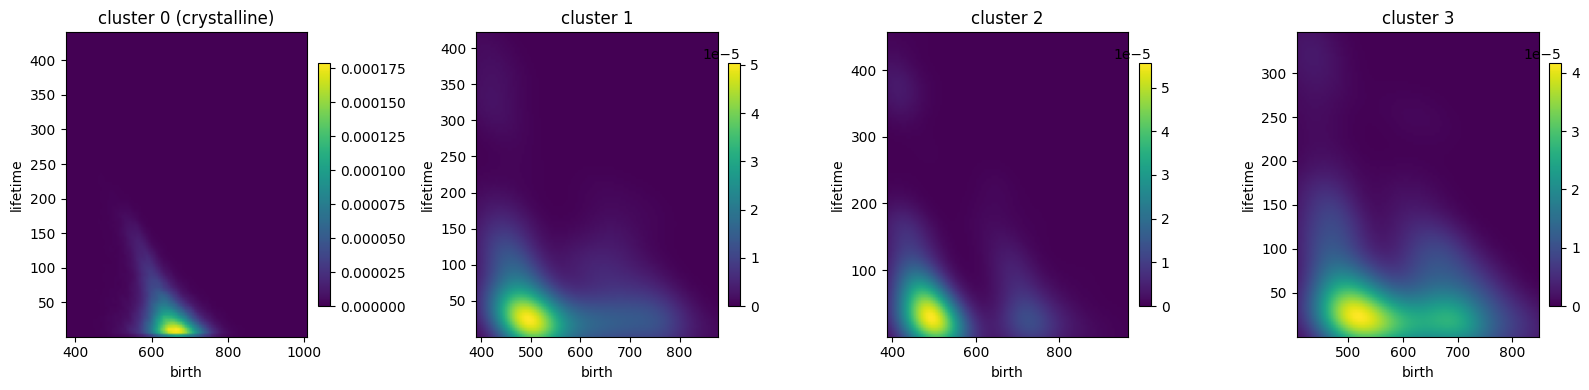

In [20]:
import json

densities_raw = json.loads(row["densities"])

cluster_densities = {
    int(label_str): (np.array(entry["density_grid"]), entry["extent"])
    for label_str, entry in densities_raw.items()
}

n_clusters = len(cluster_densities)
n_cols = 4
n_rows = int(np.ceil(n_clusters / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, (label, (density_grid, extent)) in zip(axes, cluster_densities.items()):
    im = ax.imshow(density_grid, origin='lower', extent=extent, aspect='auto', cmap='viridis')
    ax.set_title(f"cluster {label}" + (" (crystalline)" if label == 0 else ""))
    ax.set_xlabel("birth")
    ax.set_ylabel("lifetime")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# hide any unused subplot axes
for ax in axes[len(cluster_densities):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

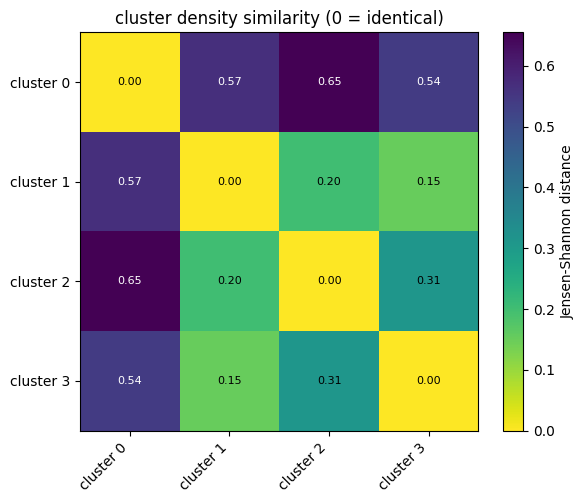

In [19]:
from scipy.spatial.distance import jensenshannon

def normalise_density(density_grid, eps=1e-10):
    flat = density_grid.ravel()
    flat = np.clip(flat, 0, None)
    flat = flat + eps
    return flat / flat.sum()

labels_sorted = sorted(cluster_densities.keys())
n = len(labels_sorted)

similarity_matrix = np.zeros((n, n))

for i, li in enumerate(labels_sorted):
    for j, lj in enumerate(labels_sorted):
        di = normalise_density(cluster_densities[li][0])
        dj = normalise_density(cluster_densities[lj][0])
        similarity_matrix[i, j] = jensenshannon(di, dj)  # 0 = identical, 1 = maximally different

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(similarity_matrix, cmap='viridis_r', vmin=0, vmax=similarity_matrix.max())

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([f"cluster {l}" for l in labels_sorted], rotation=45, ha='right')
ax.set_yticklabels([f"cluster {l}" for l in labels_sorted])

for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{similarity_matrix[i,j]:.2f}", ha='center', va='center',
                 color='white' if similarity_matrix[i,j] > similarity_matrix.max()/2 else 'black',
                 fontsize=8)

fig.colorbar(im, label="Jensen-Shannon distance")
plt.title("cluster density similarity (0 = identical)")
plt.tight_layout()
plt.show()

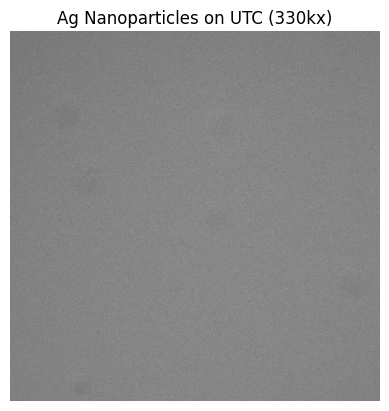

In [24]:
file = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_08.dm3")
data_dict = dm.dmReader(str(file.resolve()))

image_data = data_dict['data']

plt.imshow(image_data, cmap='gray')
plt.title("Ag Nanoparticles on UTC (330kx)")
plt.axis('off') 
plt.show()

In [26]:
from skimage.util import view_as_windows

def split_patches(patch_size, image, stride):
    blocks = view_as_windows(image, window_shape=(patch_size, patch_size), step=stride)
    patches = blocks.reshape(-1, patch_size, patch_size)

    return patches

patched = split_patches(64, image_data, 16)


In [ ]:
import glob
import os
from ncempy.io import dm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.preprocessing import StandardScaler
import umap
from sklearn.cluster import KMeans
from skimage.util import view_as_windows
from skimage.transform import resize
from scipy.ndimage import gaussian_filter
import numpy as np
from persim import PersistenceImager
from ripser import lower_star_img
import pandas as pd
from itertools import islice
import tifffile
from skimage.restoration import denoise_nl_means
from scipy.stats import gaussian_kde
import json
from persim import plot_diagrams

pimgr = PersistenceImager(
    pixel_size=16,
    birth_range=(100, 800),
    pers_range=(0, 300)
)

def PH_patch(patched_image):
    dgms = []
    for p in patched_image:      
        dgm = lower_star_img(p)
        dgm = dgm[np.isfinite(dgm[:,1])]
        dgms.append(dgm)
    vectors = []
    for dgm in dgms:
        if len(dgm) == 0:
            vectors.append(np.zeros(pimgr.resolution[0] * pimgr.resolution[1]))
        else:
            pimg = pimgr.transform(dgm)
            vec = pimg.ravel()
            vectors.append(vec)
    vectors = np.vstack(vectors)
    return dgms, vectors

def iter_patch_batches(image, patch_size=64, stride=16, batch_size=500):
    patches = []

    blocks = view_as_windows(image, (patch_size, patch_size), step=stride)
    n_rows, n_cols = blocks.shape[:2]

    for i in range(n_rows):
        for j in range(n_cols):
            patches.append(blocks[i, j])

            if len(patches) == batch_size:
                yield np.array(patches)
                patches = []

    if patches:
        yield np.array(patches)

all_vectors = []
all_dgms = []

for patch_batch in iter_patch_batches(image_data):
    #normalized_batch = [z_score_transform(p) for p in patch_batch]
    dgms, vec = PH_patch(patch_batch)
    all_vectors.append(vec)
    all_dgms.extend(dgms)

In [35]:
import json
import numpy as np
from scipy.interpolate import RegularGridInterpolator
from ripser import lower_star_img

def load_cluster_densities(row):
    """Reconstruct {label: (density_grid, extent)} from a parquet row."""
    return {
        int(label_str): (np.array(entry["density_grid"]), entry["extent"])
        for label_str, entry in json.loads(row["densities"]).items()
    }

def score_patch_against_clusters(new_patch, cluster_densities):
    dgm = lower_star_img(new_patch)
    dgm = dgm[np.isfinite(dgm[:, 1])]
    if len(dgm) == 0:
        return None, {}

    births = dgm[:, 0]
    lifetimes = dgm[:, 1] - dgm[:, 0]

    scores = {}
    for label, (density_grid, extent) in cluster_densities.items():
        b_min, b_max, l_min, l_max = extent
        grid_size = density_grid.shape[0]

        interpolator = RegularGridInterpolator(
            (np.linspace(l_min, l_max, grid_size), np.linspace(b_min, b_max, grid_size)),
            density_grid,
            bounds_error=False,
            fill_value=1e-12,
        )

        query_points = np.column_stack([lifetimes, births])
        densities = np.clip(interpolator(query_points), 1e-12, None)
        scores[label] = np.mean(np.log(densities))

    best_label = max(scores, key=scores.get)
    return best_label, scores

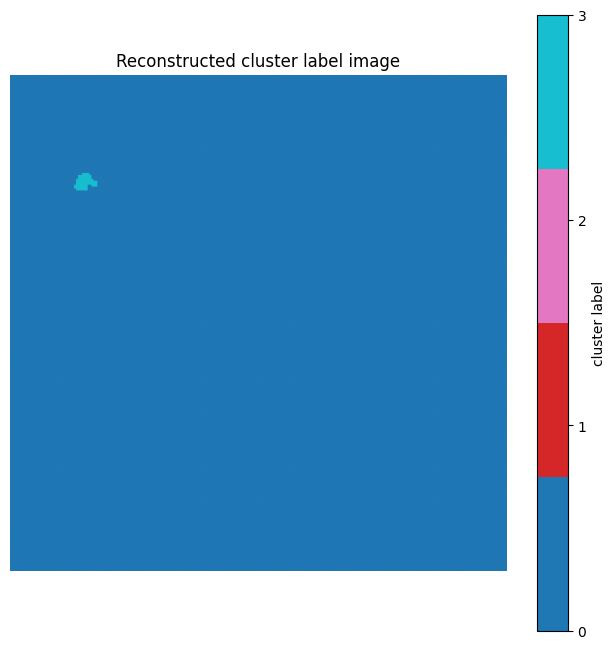

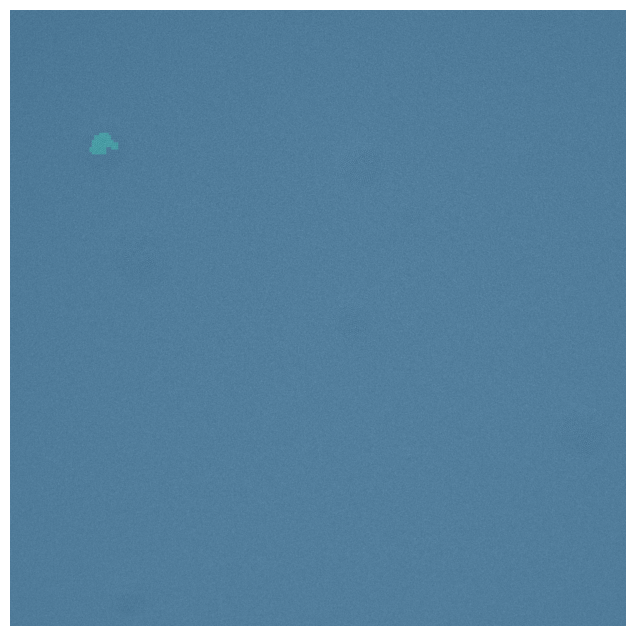

In [40]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator

def score_dgm_against_clusters(dgm, cluster_densities):
    if len(dgm) == 0:
        return None, {}

    births = dgm[:, 0]
    lifetimes = dgm[:, 1] - dgm[:, 0]

    scores = {}
    for label, (density_grid, extent) in cluster_densities.items():
        b_min, b_max, l_min, l_max = extent
        grid_size = density_grid.shape[0]

        interpolator = RegularGridInterpolator(
            (np.linspace(l_min, l_max, grid_size), np.linspace(b_min, b_max, grid_size)),
            density_grid,
            bounds_error=False,
            fill_value=1e-12,
        )

        query_points = np.column_stack([lifetimes, births])
        densities = np.clip(interpolator(query_points), 1e-12, None)
        scores[label] = np.mean(np.log(densities))

    best_label = max(scores, key=scores.get)
    return best_label, scores

best_labels = []
for dgm in all_dgms:                      # your existing diagrams for the new image
    best_label, scores = score_dgm_against_clusters(dgm, cluster_densities)
    best_labels.append(best_label)

def reconstruct_label_image(image_shape, positions, best_labels, patch_size=64, n_clusters=None):
    valid_labels = [l for l in best_labels if l is not None]
    if n_clusters is None:
        n_clusters = max(valid_labels) + 1

    H, W = image_shape
    votes = np.zeros((H, W, n_clusters), dtype=np.int32)

    for (r, c), label in zip(positions, best_labels):
        if label is None:
            continue
        votes[r:r+patch_size, c:c+patch_size, label] += 1

    label_image = np.argmax(votes, axis=2)
    covered = votes.sum(axis=2) > 0
    label_image = np.where(covered, label_image, -1)  # -1 = uncovered / never scored

    return label_image

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

label_image = reconstruct_label_image(image_data.shape, positions, best_labels, patch_size=64)

n_clusters = len(cluster_densities)
cmap = plt.get_cmap("tab10", n_clusters)
cmap.set_under("black")  # colour for uncovered (-1) pixels

plt.figure(figsize=(8, 8))
plt.imshow(label_image, cmap=cmap, vmin=0, vmax=n_clusters - 1)
plt.colorbar(ticks=range(n_clusters), label="cluster label")
plt.title("Reconstructed cluster label image")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(image_data, cmap="gray")
plt.imshow(label_image, cmap=cmap, vmin=0, vmax=n_clusters - 1, alpha=0.5)
plt.axis("off")
plt.show()
